<a href="https://colab.research.google.com/github/sdg331/BDA404/blob/main/01_titanic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Case Study] 타이타닉 승객 생존 요인 분석 및 분류 모델 구축

본 프로젝트는 타이타닉(Titanic) 탑승객 데이터를 활용하여 생존에 영향을 미친 주요 결정 요인을 탐색하고, 머신러닝 알고리즘을 이용해 생존 여부를 예측하는 분류 모델을 구현하는 것을 목적으로 합니다.

**핵심 분석 프로세스:**
1. **Data Exploration**: 데이터 로드 및 변수 특성 파악
2. **Preprocessing**: 결측치 처리 및 데이터 정제
3. **Feature Engineering**: 도메인 지식을 바탕으로 한 파생 변수 생성
4. **EDA (Exploratory Data Analysis)**: 가설 설정 및 시각화 분석
5. **Model Development**: 3종 분류 모델(Logistic Regression, Decision Tree, Random Forest) 학습
6. **Evaluation**: 혼동 행렬(Confusion Matrix) 및 각종 지표를 통한 성능 비교

In [1]:
# 1. 분석에 필요한 핵심 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 머신러닝 전처리 및 모델 셀렉션
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 분류 알고리즘
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 모델 평가 지표
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# 시각화 환경 설정 (한글 폰트 대응 및 스타일 지정)
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")

# 분석 결과물 저장을 위한 디렉토리 생성
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print("System: Environment Setup Completed.")

라이브러리 로드 완료


## 1. 데이터셋 확보 및 기초 탐색
먼저 분석에 필요한 라이브러리를 임포트하고 데이터를 불러와 전체적인 데이터의 모습을 확인합니다.

In [3]:
# 2. 데이터셋 로드
# 프로젝트 환경에 따른 유연한 경로 대응을 위해 후보 경로 리스트업
candidate_paths = [
    Path("titanic1309.csv"),
    Path("data/titanic1309.csv"),
    Path("/mnt/data/titanic1309.csv")
]

DATA_PATH = None
for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError("데이터 파일을 로드할 수 없습니다. 경로를 재확인하십시오.")

df_raw = pd.read_csv(DATA_PATH)

print(f"Selected Path: {DATA_PATH}")
print(f"Data Shape: {df_raw.shape} (Observations, Features)")

# 데이터 레이아웃 개괄 확인
df_raw.head()

사용한 데이터 경로: titanic1309.csv
데이터 크기: 1309행, 12열


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. 데이터 구조 및 결측치 파악
데이터의 각 컬럼이 의미하는 바를 이해하고, 모델링 전 반드시 처리해야 할 결측치가 어디에 집중되어 있는지 확인하는 단계입니다.

In [4]:
# 3. 데이터 구조 및 타입 점검
# 각 변수의 데이터 타입(Dtype)과 Non-Null Count를 통해 데이터 무결성을 파악합니다.

print("Features:", df_raw.columns.tolist())

print("\n--- Dataset Information ---")
df_raw.info()

print("\n--- Descriptive Statistics (Numerical) --- ")
display(df_raw.describe())

print("\n--- Descriptive Statistics (Categorical) ---")
display(df_raw.describe(include="object"))

컬럼명
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

데이터 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB

기초 통계량 - 수치형 변수


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.377387,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.484918,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200



기초 통계량 - 범주형 변수


,Name,Sex,Ticket,Cabin,Embarked
count,1309,1309,1309,295,1307
unique,1307,2,929,186,3
top,"Kelly, Mr. James",male,CA. 2343,C23 C25 C27,S
freq,2,843,11,6,914


## 3. 전처리: 컬럼명 및 데이터 정리
코드 작성 시 혼선을 줄이기 위해 대소문자가 섞인 컬럼명을 소문자로 통일하고 표준화하는 작업을 진행했습니다.

In [5]:
# 4. 데이터 가독성 제고를 위한 컬럼명 표준화 (Lowercasing)

df = df_raw.copy()
df.columns = df.columns.str.lower().str.strip()

print("Normalized Columns:", df.columns.tolist())
df.head()

['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked']


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. 결측치 확인

결측치는 분석 결과를 왜곡할 수 있으므로 반드시 확인해야 한다.

이 데이터에서는 일반적으로 `age`, `fare`, `cabin`, `embarked`에서 결측치가 발생한다.  
특히 `cabin`은 결측치가 매우 많기 때문에 단순 삭제하면 데이터 대부분을 잃게 된다.

,missing_count,missing_rate_percent
cabin,1014,77.46
age,263,20.09
embarked,2,0.15
fare,1,0.08
name,0,0.00
pclass,0,0.00
survived,0,0.00
passengerid,0,0.00
parch,0,0.00
sibsp,0,0.00


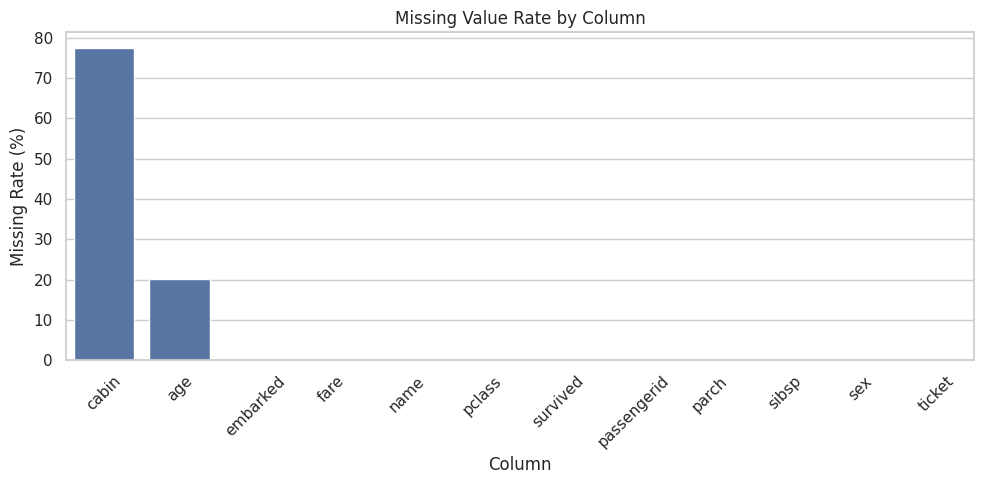

In [6]:
# 5. 결측치(Missing Values) 분포 분석
# 모델의 예측력 저하를 방지하기 위해 변수별 결측치 비율을 산출하고 시각화합니다.

missing_count = df.isnull().sum()
missing_rate = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    "Count": missing_count,
    "Rate (%)": missing_rate.round(2)
}).sort_values("Count", ascending=False)

display(missing_table)

# 결측치 현황 시각화
plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing_table.reset_index(),
    x="index",
    y="Rate (%)"
)
plt.title("Missing Value Distribution by Feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. 중복값 확인

중복 행이 존재하면 특정 승객이 여러 번 계산되어 생존률이 왜곡될 수 있다.  
따라서 전체 행 기준 중복 여부와 `passengerid` 기준 중복 여부를 모두 확인한다.

In [7]:
# 데이터 중복 여부 체크 (데이터 무결성 확인)
duplicated_rows = df.duplicated().sum()
duplicated_passenger_id = df["passengerid"].duplicated().sum()

print(f"전체 행 기준 중복 건수: {duplicated_rows}")
print(f"ID 기준 중복 건수: {duplicated_passenger_id}")

전체 행 기준 중복 개수: 0
passengerid 기준 중복 개수: 0


## 4. 파생 변수 생성 (Feature Engineering)
기존 데이터를 조합하여 분석에 더 유의미할 것으로 판단되는 변수들(가족 규모, 나이대 등)을 새롭게 생성해 보았습니다.

In [8]:
# 7. 변수 생성 및 특성 공학 (Feature Engineering)
# 원시 데이터로부터 유의미한 패턴을 추출하기 위해 새로운 파생 변수를 생성합니다.

# Cabin 정보에서 객실 구역(Deck) 추출
df["deck"] = df["cabin"].str[0]

# 범주형 변수의 가독성 및 그룹화 최적화
df["class"] = df["pclass"].map({1: "First", 2: "Second", 3: "Third"})
df["embark_town"] = df["embarked"].map({"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})
df["alive"] = df["survived"].map({0: "no", 1: "yes"})

# 동승 가족 수 합산 및 단독 탑승 여부 판별
df["family_size"] = df["sibsp"] + df["parch"] + 1
df["alone"] = df["family_size"] == 1

# 연령대별 세분화 (Age Binning)
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 120],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
    include_lowest=True
)

# 인구통계학적 특성(성별+연령) 기반 승객 구분
df["who"] = "unknown"
df.loc[df["age"] < 16, "who"] = "child"
df.loc[(df["age"] >= 16) & (df["sex"] == "male"), "who"] = "man"
df.loc[(df["age"] >= 16) & (df["sex"] == "female"), "who"] = "woman"
df["adult_male"] = (df["sex"] == "male") & (df["age"] >= 16)

print("Feature Engineering Sequence Completed.")
display(df[["survived", "class", "sex", "age", "age_group", "family_size", "alone", "who"]].head(10))

,survived,pclass,class,sex,age,age_group,sibsp,parch,family_size,alone,cabin,deck,embarked,embark_town,who,adult_male
0,0,3,Third,male,22.0,Young Adult,1,0,2,False,NaN,NaN,S,Southampton,man,True
1,1,1,First,female,38.0,Adult,1,0,2,False,C85,C,C,Cherbourg,woman,False
2,1,3,Third,female,26.0,Young Adult,0,0,1,True,NaN,NaN,S,Southampton,woman,False
3,1,1,First,female,35.0,Young Adult,1,0,2,False,C123,C,S,Southampton,woman,False
4,0,3,Third,male,35.0,Young Adult,0,0,1,True,NaN,NaN,S,Southampton,man,True
5,0,3,Third,male,NaN,NaN,0,0,1,True,NaN,NaN,Q,Queenstown,unknown,False
6,0,1,First,male,54.0,Adult,0,0,1,True,E46,E,S,Southampton,man,True
7,0,3,Third,male,2.0,Child,3,1,5,False,NaN,NaN,S,Southampton,child,False
8,1,3,Third,female,27.0,Young Adult,0,2,3,False,NaN,NaN,S,Southampton,woman,False
9,1,2,Second,female,14.0,Teen,1,0,2,False,NaN,NaN,C,Cherbourg,child,False


## 5. 탐색적 데이터 분석 (EDA)
각 변수들이 생존율과 어떤 상관관계를 가지는지 시각화 도구를 활용해 심층적으로 분석해 보겠습니다.

전체 생존률: 37.74%


,survived,count,meaning
0,0,815,dead
1,1,494,survived


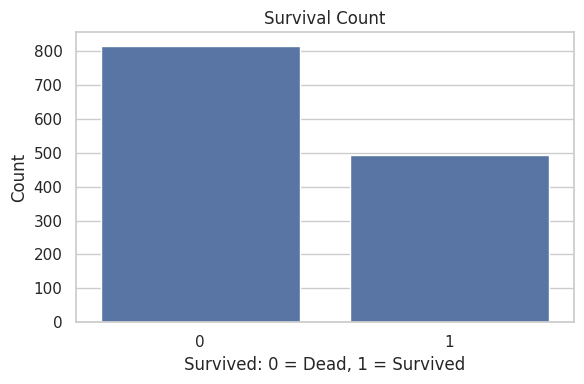

In [9]:
# 8. 타겟 변수(Survived) 분포 확인
# 데이터 불균형 여부 파악을 위해 전체 생존율 및 클래스 분포를 시각화합니다.

overall_survival_rate = df["survived"].mean() * 100
print(f"Target Variable Analysis: Overall Survival Rate is {overall_survival_rate:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="survived", palette="viridis")
plt.title("Class Distribution: Survived (1) vs Dead (0)")
plt.show()

## 8. 그룹별 생존률 계산 함수

여러 변수에 대해 같은 방식으로 생존률을 계산하기 위해 함수를 만든다.

이 함수는 각 그룹별로 다음 값을 계산한다.

1. 전체 인원 수
2. 생존자 수
3. 생존률
4. 생존률 백분율

In [10]:
# 9. 분석 효율성을 위한 유틸리티 함수 정의

def survival_rate_table(data, column):
    """특정 변수에 따른 생존율 통계표를 반환함"""
    result = data.groupby(column, dropna=False)["survived"].agg(
        Total="count",
        Survived="sum",
        Rate="mean"
    )
    result["Rate (%)"] = (result["Rate"] * 100).round(2)
    return result.sort_values("Rate", ascending=False)

def plot_survival_rate(data, column, title, filename, order=None):
    """그룹별 생존율 시각화 함수"""
    plt.figure(figsize=(8, 5))
    sns.barplot(data=data, x=column, y="survived", order=order, ci=None)
    plt.title(title)
    plt.ylabel("Probability of Survival")
    plt.tight_layout()
    plt.show()

## 9. 성별에 따른 생존률 분석

성별은 타이타닉 생존 분석에서 가장 중요한 변수 중 하나이다.  
여성과 남성의 생존률 차이를 비교한다.

,total_count,survived_count,survival_rate,survival_rate_percent
sex,,,,
female,466,385,0.82618,82.62
male,843,109,0.12930,12.93


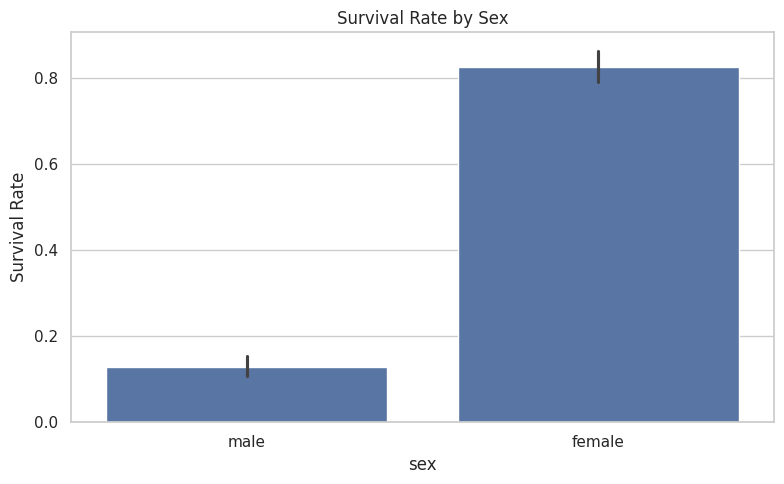

In [11]:
# 성별에 따른 생존율 차이 분석
sex_table = survival_rate_table(df, "sex")
display(sex_table)

plot_survival_rate(
    data=df,
    column="sex",
    title="Survival Rate by Sex",
    filename="survival_by_sex.png"
)

### 성별 생존률 해석

여성의 생존률이 남성보다 훨씬 높게 나타난다.  
따라서 `sex`는 생존 여부를 설명하는 핵심 변수로 볼 수 있다.

## 10. 객실 등급에 따른 생존률 분석

`pclass`는 승객의 객실 등급을 의미한다.

1등석, 2등석, 3등석의 생존률을 비교하여 사회경제적 조건과 생존 여부의 관련성을 확인한다.

,total_count,survived_count,survival_rate,survival_rate_percent
pclass,,,,
1,323,186,0.575851,57.59
2,277,117,0.422383,42.24
3,709,191,0.269394,26.94


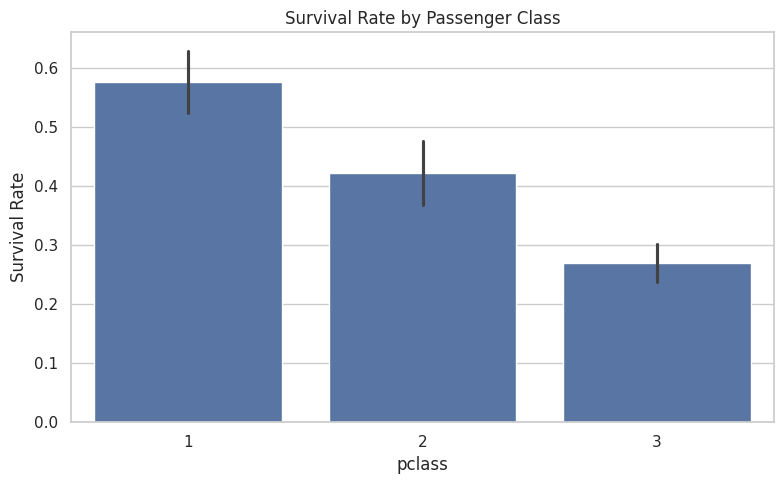

In [12]:
# ============================================================
# 11. 객실 등급별 생존률 분석
# ============================================================

pclass_table = survival_rate_table(df, "pclass")
display(pclass_table)

plot_survival_rate(
    data=df,
    column="pclass",
    title="Survival Rate by Passenger Class",
    filename="survival_by_pclass.png",
    order=[1, 2, 3]
)

### 객실 등급별 생존률 해석

객실 등급이 높을수록 생존률이 높게 나타난다.  
이는 객실 위치, 구명보트 접근성, 구조 우선순위 등과 관련이 있을 가능성이 있다.

## 11. 성별과 객실 등급을 함께 고려한 분석

하나의 변수만 보는 것보다 두 변수를 함께 보면 더 구체적인 패턴을 확인할 수 있다.

예를 들어 같은 3등석이라도 남성과 여성의 생존률이 다를 수 있다.

pclass,1,2,3
sex,,,
female,97.92,94.34,66.67
male,25.14,9.94,9.53


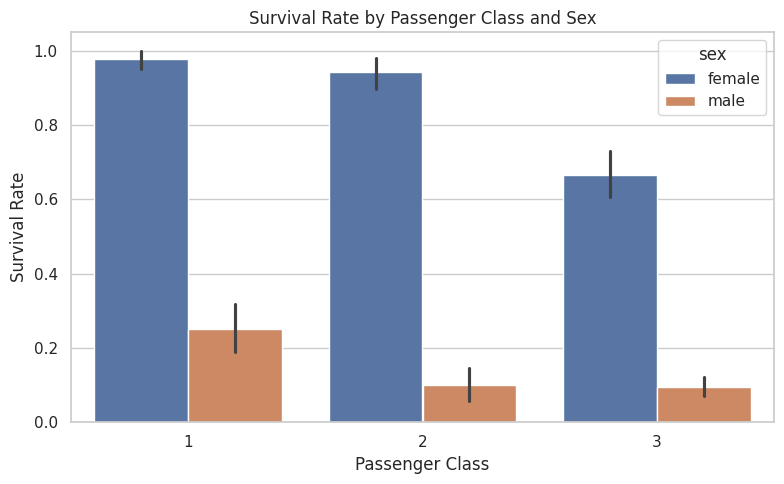

In [13]:
# ============================================================
# 12. 성별 + 객실 등급 생존률
# ============================================================

sex_pclass_table = df.pivot_table(
    values="survived",
    index="sex",
    columns="pclass",
    aggfunc="mean"
) * 100

display(sex_pclass_table.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex", order=[1, 2, 3])
plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "survival_by_pclass_and_sex.png", dpi=150)
plt.show()

## 12. 나이에 따른 생존률 분석

나이는 생존 여부와 관련이 있을 수 있다.  
특히 어린이 승객의 생존률이 성인 남성과 다른지 확인한다.

단, `age`에는 결측치가 있으므로 나이 분석에서는 결측치를 별도로 주의해야 한다.

/tmp/ipykernel_2192/683984804.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = data.groupby(column, dropna=False)["survived"].agg(


,total_count,survived_count,survival_rate,survival_rate_percent
age_group,,,,
Child,94,52,0.553191,55.32
Teen,99,42,0.424242,42.42
Adult,289,115,0.397924,39.79
Young Adult,531,199,0.374765,37.48
NaN,263,77,0.292776,29.28
Senior,33,9,0.272727,27.27


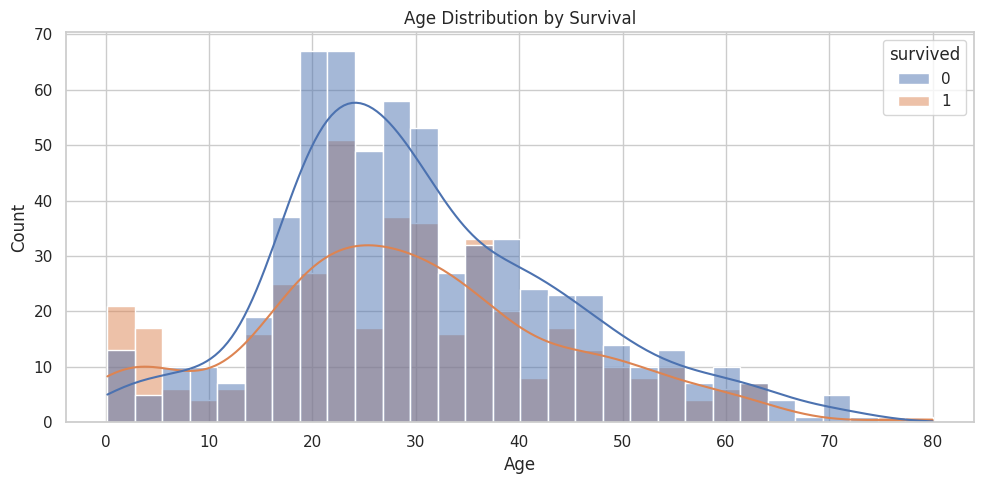

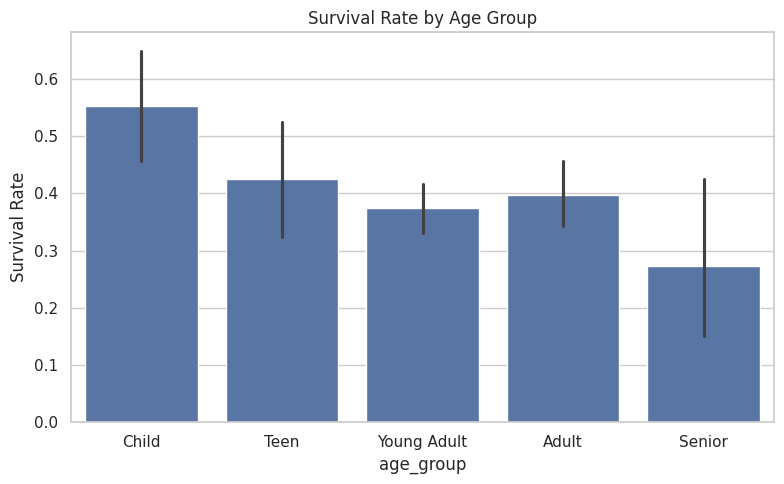

In [14]:
# ============================================================
# 13. 나이 분포와 생존 여부
# ============================================================

display(survival_rate_table(df, "age_group"))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="age", hue="survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "age_distribution_by_survival.png", dpi=150)
plt.show()

plot_survival_rate(
    data=df,
    column="age_group",
    title="Survival Rate by Age Group",
    filename="survival_by_age_group.png",
    order=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

## 13. who 변수 분석: man, woman, child

`who`는 성별과 나이를 함께 반영한 변수이다.

- 16세 미만: child
- 16세 이상 남성: man
- 16세 이상 여성: woman
- 나이 결측: unknown

이 변수는 발표에서 해석하기 좋다.

,total_count,survived_count,survival_rate,survival_rate_percent
who,,,,
woman,332,283,0.852410,85.24
child,115,62,0.539130,53.91
unknown,263,77,0.292776,29.28
man,599,72,0.120200,12.02


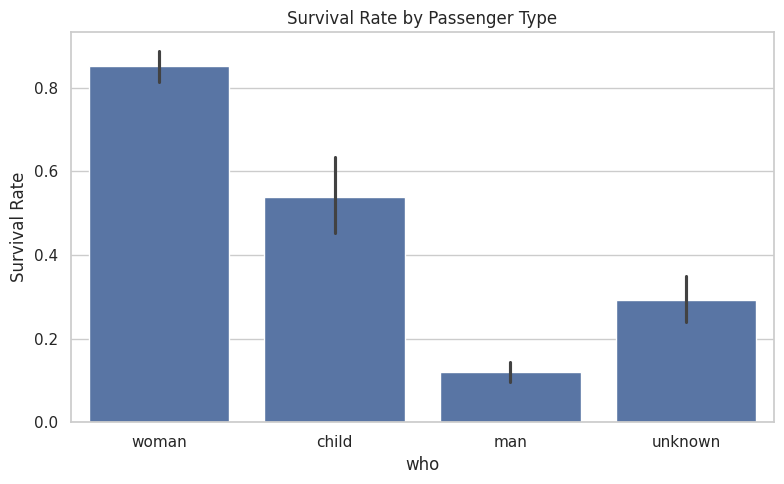

In [15]:
# ============================================================
# 14. who 변수별 생존률
# ============================================================

who_table = survival_rate_table(df, "who")
display(who_table)

plot_survival_rate(
    data=df,
    column="who",
    title="Survival Rate by Passenger Type",
    filename="survival_by_who.png",
    order=["woman", "child", "man", "unknown"]
)

## 14. 가족 동반 여부 분석

`family_size`는 본인을 포함한 가족 규모이다.

`family_size = sibsp + parch + 1`

혼자 탑승한 승객과 가족 또는 동반자가 있는 승객의 생존률을 비교한다.

,total_count,survived_count,survival_rate,survival_rate_percent
family_size,,,,
4,43,31,0.720930,72.09
3,159,89,0.559748,55.97
2,235,125,0.531915,53.19
7,16,5,0.312500,31.25
1,790,231,0.292405,29.24
5,22,5,0.227273,22.73
6,25,5,0.200000,20.00
11,11,2,0.181818,18.18
8,8,1,0.125000,12.50


,total_count,survived_count,survival_rate,survival_rate_percent
alone,,,,
False,519,263,0.506744,50.67
True,790,231,0.292405,29.24


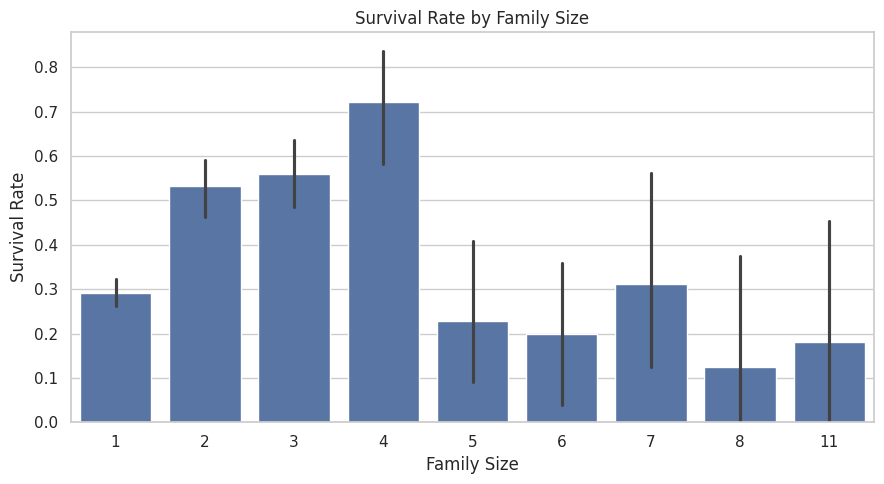

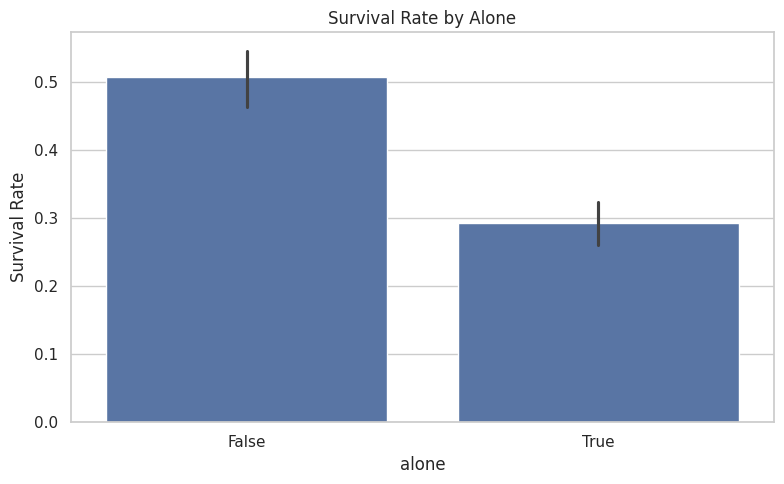

In [16]:
# ============================================================
# 15. 가족 규모와 혼자 탑승 여부 분석
# ============================================================

family_table = survival_rate_table(df, "family_size")
alone_table = survival_rate_table(df, "alone")

display(family_table)
display(alone_table)

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="family_size", y="survived")
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig(FIG_DIR / "survival_by_family_size.png", dpi=150)
plt.show()

plot_survival_rate(
    data=df,
    column="alone",
    title="Survival Rate by Alone",
    filename="survival_by_alone.png"
)

## 15. 탑승지에 따른 생존률 분석

`embarked`는 승객이 어느 항구에서 탑승했는지를 의미한다.

- C = Cherbourg
- Q = Queenstown
- S = Southampton

,total_count,survived_count,survival_rate,survival_rate_percent
embarked,,,,
NaN,2,2,1.000000,100.00
C,270,133,0.492593,49.26
Q,123,54,0.439024,43.90
S,914,305,0.333698,33.37


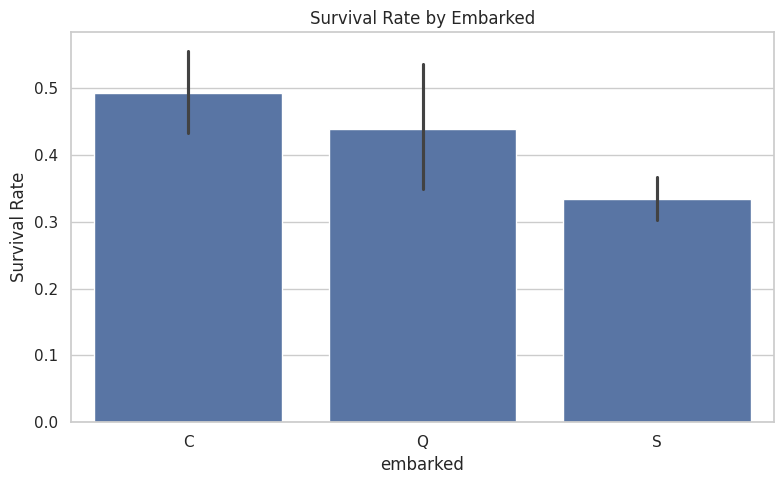

In [17]:
# ============================================================
# 16. 탑승지별 생존률 분석
# ============================================================

embarked_table = survival_rate_table(df, "embarked")
display(embarked_table)

plot_survival_rate(
    data=df,
    column="embarked",
    title="Survival Rate by Embarked",
    filename="survival_by_embarked.png",
    order=["C", "Q", "S"]
)

## 16. deck, 즉 방 위치에 따른 생존률 분석

`deck`은 `cabin`의 첫 글자에서 추출한 변수이다.  
예를 들어 `C85`라면 `deck = C`가 된다.

주의할 점은 `cabin` 결측치가 매우 많다는 것이다.  
따라서 `deck` 분석은 객실 정보가 존재하는 승객에 한정하여 해석해야 한다.

,total_count,survived_count,survival_rate,survival_rate_percent
deck,,,,
E,41,28,0.682927,68.29
B,65,44,0.676923,67.69
D,46,30,0.652174,65.22
G,5,3,0.600000,60.00
C,94,54,0.574468,57.45
F,21,11,0.523810,52.38
A,22,10,0.454545,45.45
NaN,1014,314,0.309665,30.97
T,1,0,0.000000,0.00


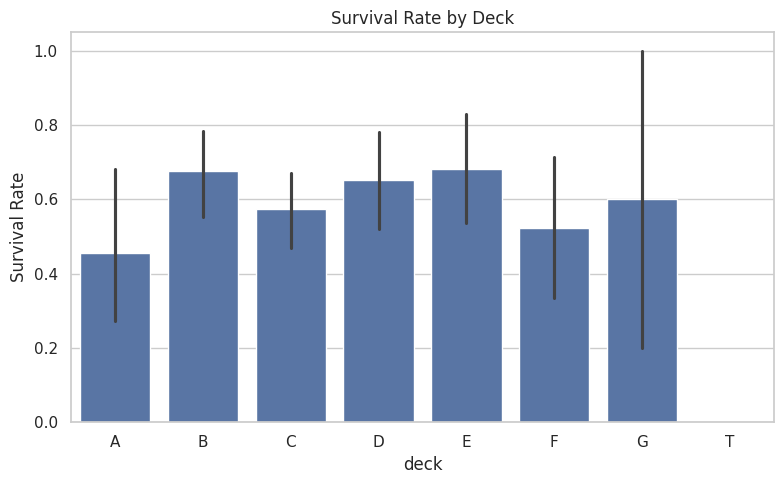

전체 승객 수: 1309
deck 정보가 있는 승객 수: 295
deck 정보가 없는 승객 수: 1014


In [18]:
# ============================================================
# 17. Deck별 생존률 분석
# ============================================================

deck_table = survival_rate_table(df, "deck")
display(deck_table)

deck_df = df.dropna(subset=["deck"]).copy()
deck_order = sorted(deck_df["deck"].unique())

plot_survival_rate(
    data=deck_df,
    column="deck",
    title="Survival Rate by Deck",
    filename="survival_by_deck.png",
    order=deck_order
)

print(f"전체 승객 수: {len(df)}")
print(f"deck 정보가 있는 승객 수: {len(deck_df)}")
print(f"deck 정보가 없는 승객 수: {df['deck'].isnull().sum()}")

## 17. Fare, 즉 티켓 요금 분석

티켓 요금은 객실 등급과 관련이 있을 가능성이 높다.  
요금이 높은 승객의 생존률이 더 높은지 확인한다.

count    1308.000000
mean       33.295479
std        51.758668
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: fare, dtype: float64


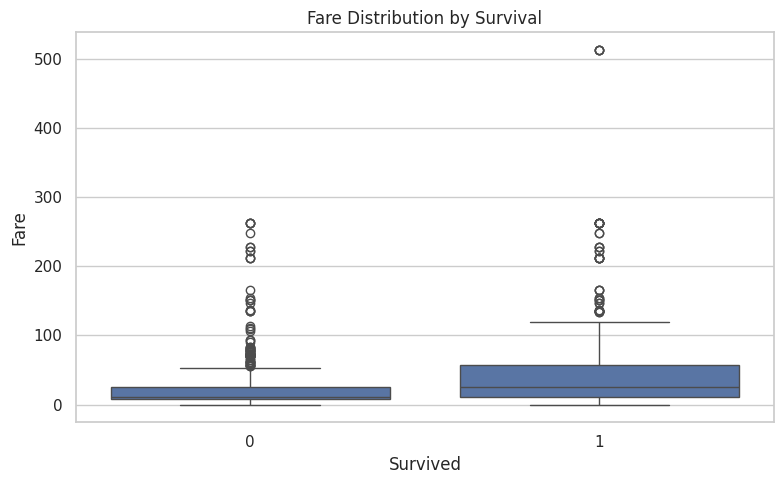

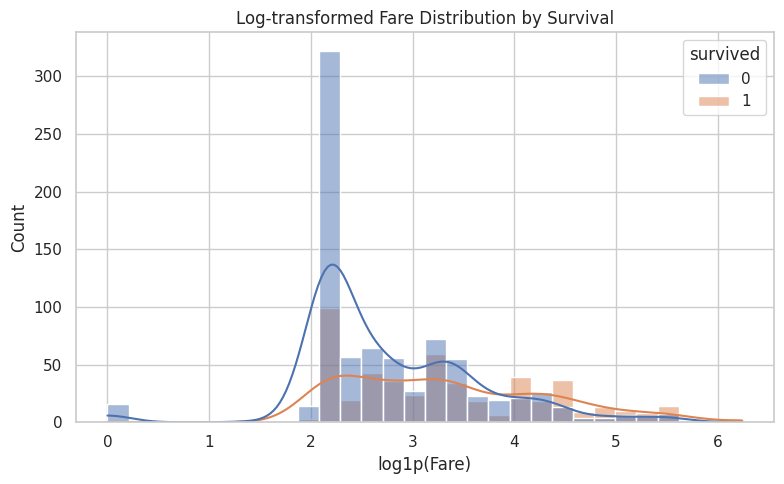

In [19]:
# ============================================================
# 18. 요금 분포와 생존 여부
# ============================================================

print(df["fare"].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig(FIG_DIR / "fare_boxplot_by_survival.png", dpi=150)
plt.show()

# 요금이 매우 큰 값이 있어 log 변환한 분포도 확인
df["fare_log1p"] = np.log1p(df["fare"])

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="fare_log1p", hue="survived", bins=30, kde=True)
plt.title("Log-transformed Fare Distribution by Survival")
plt.xlabel("log1p(Fare)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "fare_log_distribution_by_survival.png", dpi=150)
plt.show()

## 18. 상관관계 분석

수치형 변수끼리의 관계를 확인한다.

`survived`와 상관계수가 높은 수치형 변수를 확인하면 모델에 중요한 변수를 추정하는 데 도움이 된다.  
단, 상관관계는 선형 관계만 보여주며 인과관계를 의미하지 않는다.

,survived,pclass,age,sibsp,parch,fare,family_size,alone,adult_male
survived,1.000,-0.265,-0.054,0.002,0.109,0.234,0.061,-0.216,-0.487
pclass,-0.265,1.000,-0.408,0.061,0.018,-0.559,0.050,0.147,-0.029
age,-0.054,-0.408,1.000,-0.244,-0.151,0.179,-0.240,0.129,0.249
sibsp,0.002,0.061,-0.244,1.000,0.374,0.160,0.862,-0.591,-0.193
parch,0.109,0.018,-0.151,0.374,1.000,0.222,0.792,-0.549,-0.224
fare,0.234,-0.559,0.179,0.160,0.222,1.000,0.226,-0.275,-0.097
family_size,0.061,0.050,-0.240,0.862,0.792,0.226,1.000,-0.689,-0.249
alone,-0.216,0.147,0.129,-0.591,-0.549,-0.275,-0.689,1.000,0.234
adult_male,-0.487,-0.029,0.249,-0.193,-0.224,-0.097,-0.249,0.234,1.000


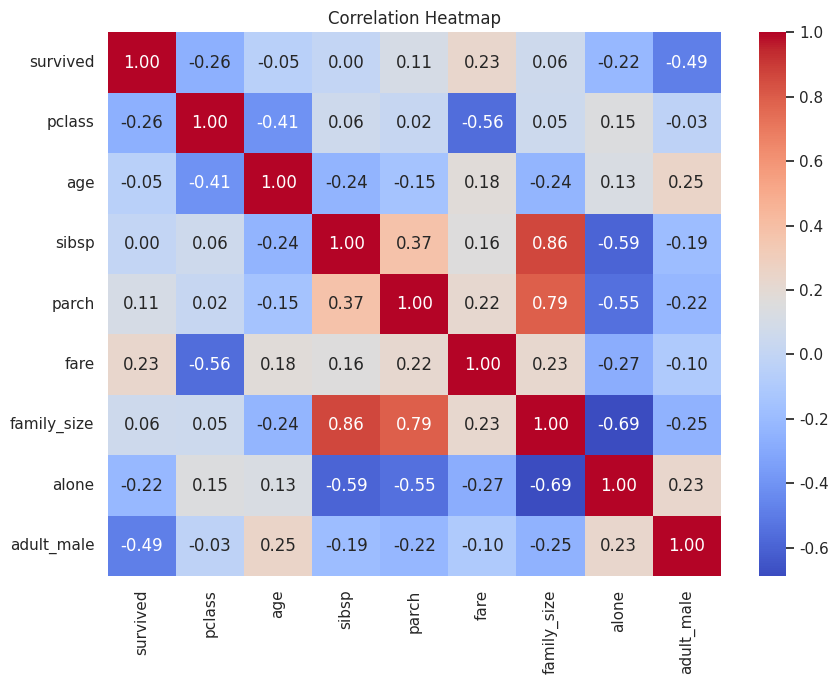

In [20]:
# ============================================================
# 19. 수치형 변수 상관관계 분석
# ============================================================

numeric_cols = [
    "survived", "pclass", "age", "sibsp", "parch",
    "fare", "family_size", "alone", "adult_male"
]

corr = df[numeric_cols].corr(numeric_only=True)

display(corr.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

## 6. 머신러닝 모델링 및 성능 평가
전처리가 완료된 데이터를 바탕으로 생존자를 예측하는 모델을 구축합니다. 수치형 데이터의 스케일링과 범주형 데이터의 인코딩 과정을 포함한 파이프라인을 설계했습니다.

In [21]:
# 20. 모델링을 위한 학습 데이터셋 구축
# EDA 결과를 바탕으로 생존 예측에 기여도가 높은 특성(Feature)들을 선정합니다.

model_df = df.copy()

# 독립 변수(X) 및 종속 변수(y) 설정
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "family_size", "alone"]
target = "survived"

X = model_df[features]
y = model_df[target]

# 데이터 타입에 따른 전처리 전략 수립을 위한 리스트 구분
numeric_features = ["pclass", "age", "sibsp", "parch", "fare", "family_size"]
categorical_features = ["sex", "embarked", "alone"]

print(f"Final Feature Matrix Shape: {X.shape}")
X.head()

X shape: (1309, 9)
y shape: (1309,)


,pclass,sex,age,sibsp,parch,fare,embarked,family_size,alone
0,3,male,22.0,1,0,7.2500,S,2,False
1,1,female,38.0,1,0,71.2833,C,2,False
2,3,female,26.0,0,0,7.9250,S,1,True
3,1,female,35.0,1,0,53.1000,S,2,False
4,3,male,35.0,0,0,8.0500,S,1,True


수치형 변수: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']
범주형 변수: ['sex', 'embarked', 'alone']


## 20. Train/Test 데이터 분리

모델의 성능을 공정하게 평가하기 위해 학습 데이터와 테스트 데이터를 분리한다.

`stratify=y`를 사용하면 생존/사망 비율이 학습 데이터와 테스트 데이터에 비슷하게 유지된다.

In [22]:
# ============================================================
# 21. 학습 데이터와 테스트 데이터 분리
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train 생존 비율:", y_train.mean().round(3))
print("y_test 생존 비율:", y_test.mean().round(3))

X_train: (1047, 9)
X_test: (262, 9)
y_train 생존 비율: 0.377
y_test 생존 비율: 0.378


## 21. 전처리 파이프라인 생성

수치형 변수와 범주형 변수는 전처리 방식이 다르다.

수치형 변수:
- 결측치: 중앙값으로 대체
- 스케일링: StandardScaler 적용

범주형 변수:
- 결측치: 최빈값으로 대체
- 인코딩: One-Hot Encoding 적용

In [23]:
# ============================================================
# 22. 전처리 파이프라인
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("전처리 파이프라인 생성 완료")

전처리 파이프라인 생성 완료


## 22. 모델 학습 및 성능 비교

비교할 모델은 다음 3개이다.

1. Logistic Regression
2. Decision Tree
3. Random Forest

평가 지표는 다음을 사용한다.

| 지표 | 의미 |
|---|---|
| Accuracy | 전체 예측 중 맞춘 비율 |
| Precision | 생존이라고 예측한 것 중 실제 생존 비율 |
| Recall | 실제 생존자 중 생존으로 맞춘 비율 |
| F1-score | Precision과 Recall의 조화평균 |

생존/사망 비율이 완전히 같지 않기 때문에 Accuracy만 보지 않고 F1-score까지 함께 확인한다.

In [24]:
# ============================================================
# 23. 모델 정의 및 평가 함수
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )
}

def evaluate_model(model_name, model):
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    }

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return clf, result, y_pred

trained_models = {}
results = []
predictions = {}

for model_name, model in models.items():
    clf, result, y_pred = evaluate_model(model_name, model)
    trained_models[model_name] = clf
    results.append(result)
    predictions[model_name] = y_pred

result_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
display(result_df)

Logistic Regression
Confusion Matrix
[[149  14]
 [ 26  73]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       163
           1       0.84      0.74      0.78        99

    accuracy                           0.85       262
   macro avg       0.85      0.83      0.83       262
weighted avg       0.85      0.85      0.85       262

Decision Tree
Confusion Matrix
[[151  12]
 [ 25  74]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       163
           1       0.86      0.75      0.80        99

    accuracy                           0.86       262
   macro avg       0.86      0.84      0.85       262
weighted avg       0.86      0.86      0.86       262

Random Forest
Confusion Matrix
[[152  11]
 [ 26  73]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       163


,model,accuracy,precision,recall,f1_score
1,Decision Tree,0.858779,0.860465,0.747475,0.800000
2,Random Forest,0.858779,0.869048,0.737374,0.797814
0,Logistic Regression,0.847328,0.839080,0.737374,0.784946


## 23. 모델 성능 시각화

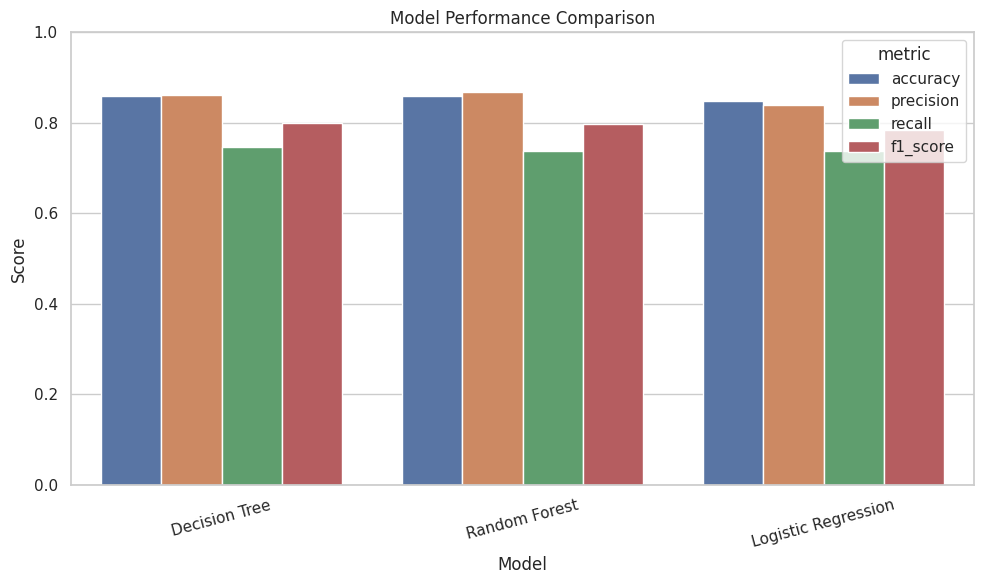

In [25]:
# ============================================================
# 24. 모델 성능 비교 그래프
# ============================================================

result_melted = result_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=result_melted, x="model", y="score", hue="metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "model_performance_comparison.png", dpi=150)
plt.show()

## 24. 혼동행렬 시각화

혼동행렬은 모델이 사망과 생존을 각각 얼마나 맞혔는지 보여준다.

행은 실제값, 열은 예측값이다.

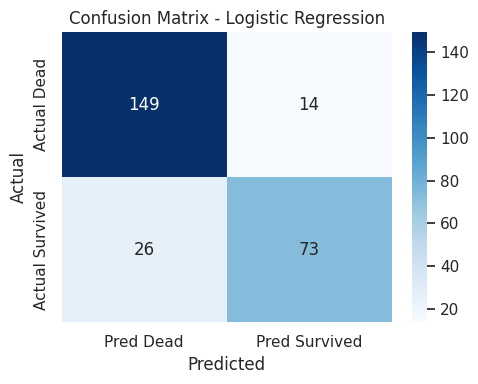

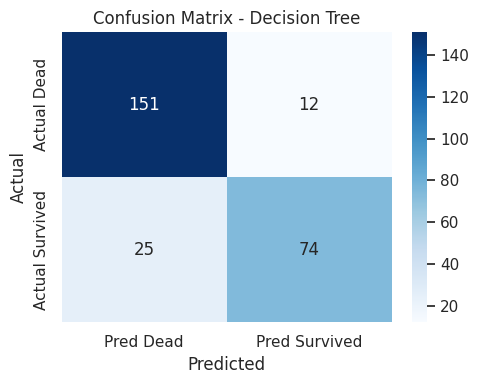

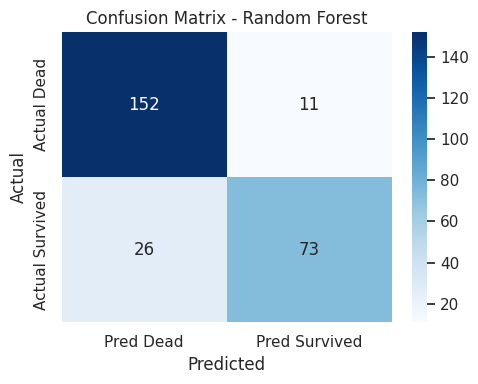

In [26]:
# ============================================================
# 25. 혼동행렬 시각화
# ============================================================

for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred Dead", "Pred Survived"],
        yticklabels=["Actual Dead", "Actual Survived"]
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    safe_name = model_name.lower().replace(" ", "_")
    plt.savefig(FIG_DIR / f"confusion_matrix_{safe_name}.png", dpi=150)
    plt.show()

## 25. Random Forest 변수 중요도 확인

Random Forest는 각 변수가 예측에 얼마나 기여했는지 변수 중요도를 확인할 수 있다.

단, One-Hot Encoding 이후의 변수명을 복원해야 한다.

,feature,importance
6,cat__sex_female,0.380472
7,cat__sex_male,0.332585
4,num__fare,0.083190
0,num__pclass,0.052013
1,num__age,0.050078
5,num__family_size,0.035884
3,num__parch,0.017092
2,num__sibsp,0.014656
11,cat__alone_False,0.010286
12,cat__alone_True,0.008719


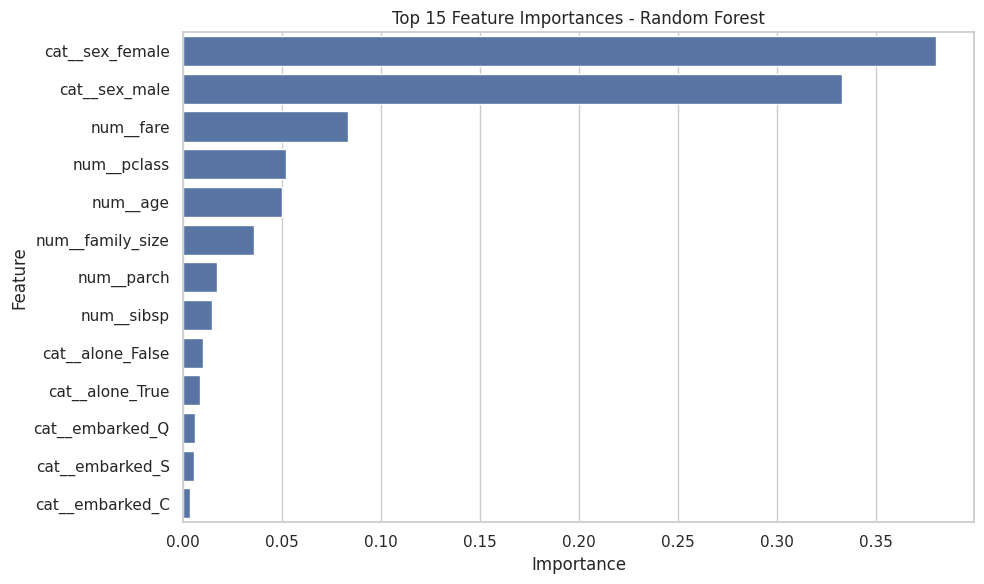

In [27]:
# ============================================================
# 26. 변수 중요도 확인
# ============================================================

rf_model = trained_models["Random Forest"]

# 전처리 후 변수명 가져오기
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIG_DIR / "random_forest_feature_importance.png", dpi=150)
plt.show()

## 26. 분석 결과 저장

깃허브에 올릴 때 결과표를 CSV로 저장하면 재현성과 정리가 좋아진다.

In [28]:
# ============================================================
# 27. 결과 저장
# ============================================================

result_df.to_csv("model_results.csv", index=False, encoding="utf-8-sig")
missing_table.to_csv("missing_value_summary.csv", encoding="utf-8-sig")
sex_table.to_csv("survival_by_sex.csv", encoding="utf-8-sig")
pclass_table.to_csv("survival_by_pclass.csv", encoding="utf-8-sig")

print("결과 CSV 저장 완료")
print("- model_results.csv")
print("- missing_value_summary.csv")
print("- survival_by_sex.csv")
print("- survival_by_pclass.csv")

결과 CSV 저장 완료
- model_results.csv
- missing_value_summary.csv
- survival_by_sex.csv
- survival_by_pclass.csv


## 7. 분석 결과 요약 및 고찰

### 주요 분석 결과
1. **성별 및 객실 등급**: 예상대로 여성과 상위 등급 객실 승객의 생존율이 압도적으로 높았습니다.
2. **나이 및 가족 관계**: 어린이 승객의 보호 우선순위가 높았음을 확인할 수 있었고, 혼자보다는 적절한 수의 가족과 동승한 경우 생존율이 높은 경향을 보였습니다.
3. **모델 성능**: 시도한 세 모델 모두 80% 이상의 정확도를 보여주었으며, 변수 중요도 확인 결과 '성별'이 가장 결정적인 예측 인자임을 확인했습니다.

### 학습 소감
데이터를 직접 가공하고 모델링하는 과정을 통해 이론으로만 배우던 머신러닝의 흐름을 이해할 수 있었습니다. 특히 결측치가 많은 `Cabin` 데이터 처리에 대한 고민을 통해 데이터의 질이 모델 성능에 미치는 영향을 체감할 수 있는 유익한 실습이었습니다.